## LangGraph Open Deep Research - Supervisor-Researcher Architecture

In this notebook, we'll explore the **supervisor-researcher delegation architecture** for conducting deep research with LangGraph.

You can visit this repository to see the original application: [Open Deep Research](https://github.com/langchain-ai/open_deep_research)

Let's jump in!

## What We're Building

This implementation uses a **hierarchical delegation pattern** where:

1. **User Clarification** - Optionally asks clarifying questions to understand the research scope
2. **Research Brief Generation** - Transforms user messages into a structured research brief
3. **Supervisor** - A lead researcher that analyzes the brief and delegates research tasks
4. **Parallel Researchers** - Multiple sub-agents that conduct focused research simultaneously
5. **Research Compression** - Each researcher synthesizes their findings
6. **Final Report** - All findings are combined into a comprehensive report

![Architecture Diagram](https://private-user-images.githubusercontent.com/181020547/465824799-12a2371b-8be2-4219-9b48-90503eb43c69.png?jwt=eyJ0eXAiOiJKV1QiLCJhbGciOiJIUzI1NiJ9.eyJpc3MiOiJnaXRodWIuY29tIiwiYXVkIjoicmF3LmdpdGh1YnVzZXJjb250ZW50LmNvbSIsImtleSI6ImtleTUiLCJleHAiOjE3NjAwNDgyMzcsIm5iZiI6MTc2MDA0NzkzNywicGF0aCI6Ii8xODEwMjA1NDcvNDY1ODI0Nzk5LTEyYTIzNzFiLThiZTItNDIxOS05YjQ4LTkwNTAzZWI0M2M2OS5wbmc_WC1BbXotQWxnb3JpdGhtPUFXUzQtSE1BQy1TSEEyNTYmWC1BbXotQ3JlZGVudGlhbD1BS0lBVkNPRFlMU0E1M1BRSzRaQSUyRjIwMjUxMDA5JTJGdXMtZWFzdC0xJTJGczMlMkZhd3M0X3JlcXVlc3QmWC1BbXotRGF0ZT0yMDI1MTAwOVQyMjEyMTdaJlgtQW16LUV4cGlyZXM9MzAwJlgtQW16LVNpZ25hdHVyZT1iYTRmYTAzYjkzYjA2MGE4ZTZlYjQ4ODU1OWIwY2VlZWU0Mzk0YzdmMjQ1YTlhMDMyNmI3NWNlZTQxNDdlZGViJlgtQW16LVNpZ25lZEhlYWRlcnM9aG9zdCJ9.a8477QD1J4Lrmys7jB8gt_H5pdiKBsKsu3npEqZjEpo)

This differs from a section-based approach by allowing dynamic task decomposition based on the research question, rather than predefined sections.

## Dependencies

You'll need API keys for Anthropic (for the LLM) and Tavily (for web search). We'll configure the system to use Anthropic's Claude Sonnet 4 exclusively.

In [1]:
import os
from dotenv import load_dotenv

# Load environment variables from .env file
load_dotenv()

# Verify required API keys are present
required_keys = ["ANTHROPIC_API_KEY", "TAVILY_API_KEY"]
missing_keys = [key for key in required_keys if not os.getenv(key)]

if missing_keys:
    print(f"Warning: Missing API keys in .env file: {', '.join(missing_keys)}")
    print("Please add them to your .env file before proceeding")
else:
    print("All required API keys loaded successfully")
    
# Check for optional LangSmith tracing configuration
if os.getenv("LANGCHAIN_API_KEY"):
    print("LangSmith tracing enabled")

All required API keys loaded successfully
LangSmith tracing enabled


## Task 1: State Definitions

The state structure is hierarchical with three levels:

### Agent State (Top Level)
Contains the overall conversation messages, research brief, accumulated notes, and final report.

### Supervisor State (Middle Level)
Manages the research supervisor's messages, research iterations, and coordinating parallel researchers.

### Researcher State (Bottom Level)
Each individual researcher has their own message history, tool call iterations, and research findings.

We also have structured outputs for tool calling:
- **ConductResearch** - Tool for supervisor to delegate research to a sub-agent
- **ResearchComplete** - Tool to signal research phase is done
- **ClarifyWithUser** - Structured output for asking clarifying questions
- **ResearchQuestion** - Structured output for the research brief

Let's import these from our library: [`open_deep_library/state.py`](open_deep_library/state.py)

In [2]:
# Import state definitions from the library
from open_deep_library.state import (
    # Main workflow states
    AgentState,           # Lines 65-72: Top-level agent state with messages, research_brief, notes, final_report
    AgentInputState,      # Lines 62-63: Input state is just messages
    
    # Supervisor states
    SupervisorState,      # Lines 74-81: Supervisor manages research delegation and iterations
    
    # Researcher states
    ResearcherState,      # Lines 83-90: Individual researcher with messages and tool iterations
    ResearcherOutputState, # Lines 92-96: Output from researcher (compressed research + raw notes)
    
    # Structured outputs for tool calling
    ConductResearch,      # Lines 15-19: Tool for delegating research to sub-agents
    ResearchComplete,     # Lines 21-22: Tool to signal research completion
    ClarifyWithUser,      # Lines 30-41: Structured output for user clarification
    ResearchQuestion,     # Lines 43-48: Structured output for research brief
)

#### ❓ Question 1:
 Explain the interrelationships between the three states.  Why don't we just make a single huge state?
#### ✅ Answer

 - The main Agent states are just handling the initial input with the user, clarifying questions, creating research brief and handoff details with supervisor agent
 - The Supervisor state handles spawning of multiple parallel research agents based the brief from previous step
 - These individual reserachers use ResearcherState to hand off the generated research notes back for report generation
 - These are individually maintained to hold only details about the task at hand and their output, enforcing isolating and encapsulation
 - Each researcher needs its own state so that it can run parallelly and independently without overlap with other researcher agents
 - This also allows individual token limit management, where if a specific researcher agent reaches limit, it can reduce its own context, without impacting other research topics
 - This also improves maintainability as we can try to test and track individual agent's activity instead of a massive list of interrelated message list. 


#### App Flow 

## Task 2: Utility Functions and Tools

The system uses several key utilities:

### Search Tools
- **tavily_search** - Async web search with automatic summarization to stay within token limits
- Supports Anthropic native web search and Tavily API

### Reflection Tools
- **think_tool** - Allows researchers to reflect on their progress and plan next steps (ReAct pattern)

### Helper Utilities
- **get_all_tools** - Assembles the complete toolkit (search + MCP + reflection)
- **get_today_str** - Provides current date context for research
- Token limit handling utilities for graceful degradation

These are defined in [`open_deep_library/utils.py`](open_deep_library/utils.py)

In [3]:
# Import utility functions and tools from the library
from open_deep_library.utils import (
    # Search tool - Lines 43-136: Tavily search with automatic summarization
    tavily_search,
    
    # Reflection tool - Lines 219-244: Strategic thinking tool for ReAct pattern
    think_tool,
    
    # Tool assembly - Lines 569-597: Get all configured tools
    get_all_tools,
    
    # Date utility - Lines 872-879: Get formatted current date
    get_today_str,
    
    # Supporting utilities for error handling
    get_api_key_for_model,          # Lines 892-914: Get API keys from config or env
    is_token_limit_exceeded,         # Lines 665-701: Detect token limit errors
    get_model_token_limit,           # Lines 831-846: Look up model's token limit
    remove_up_to_last_ai_message,    # Lines 848-866: Truncate messages for retry
    anthropic_websearch_called,      # Lines 607-637: Detect Anthropic native search usage
    openai_websearch_called,         # Lines 639-658: Detect OpenAI native search usage
    get_notes_from_tool_calls,       # Lines 599-601: Extract notes from tool messages
)

### ❓ Question 2:  

What are the advantages and disadvantages of importing these components instead of including them in the notebook?

### ✅ Answer:
- Given the complexity and length of code, having code in a separate code file is helpful for readability without getting a single large notebook
- This also makes the code files reusable readily for other projects or notebooks
- This lets the learning focus of core concepts instead of the verbose plubming of code
- Can easily unit test parts as needed
- A disadvantage is that code changes in the component code files requires kernel restart, and manage package installations

## Task 3: Configuration System

The configuration system controls:

### Research Behavior
- **allow_clarification** - Whether to ask clarifying questions before research
- **max_concurrent_research_units** - How many parallel researchers can run (default: 5)
- **max_researcher_iterations** - How many times supervisor can delegate research (default: 6)
- **max_react_tool_calls** - Tool call limit per researcher (default: 10)

### Model Configuration
- **research_model** - Model for research and supervision (we'll use Anthropic)
- **compression_model** - Model for synthesizing findings
- **final_report_model** - Model for writing the final report
- **summarization_model** - Model for summarizing web search results

### Search Configuration
- **search_api** - Which search API to use (ANTHROPIC, TAVILY, or NONE)
- **max_content_length** - Character limit before summarization

Defined in [`open_deep_library/configuration.py`](open_deep_library/configuration.py)

In [4]:
# Import configuration from the library
from open_deep_library.configuration import (
    Configuration,    # Lines 38-247: Main configuration class with all settings
    SearchAPI,        # Lines 11-17: Enum for search API options (ANTHROPIC, TAVILY, NONE)
)

## Task 4: Prompt Templates

The system uses carefully engineered prompts for each phase:

### Phase 1: Clarification
**clarify_with_user_instructions** - Analyzes if the research scope is clear or needs clarification

### Phase 2: Research Brief
**transform_messages_into_research_topic_prompt** - Converts user messages into a detailed research brief

### Phase 3: Supervisor
**lead_researcher_prompt** - System prompt for the supervisor that manages delegation strategy

### Phase 4: Researcher
**research_system_prompt** - System prompt for individual researchers conducting focused research

### Phase 5: Compression
**compress_research_system_prompt** - Prompt for synthesizing research findings without losing information

### Phase 6: Final Report
**final_report_generation_prompt** - Comprehensive prompt for writing the final report

All prompts are defined in [`open_deep_library/prompts.py`](open_deep_library/prompts.py)

In [5]:
# Import prompt templates from the library
from open_deep_library.prompts import (
    clarify_with_user_instructions,                    # Lines 3-41: Ask clarifying questions
    transform_messages_into_research_topic_prompt,     # Lines 44-77: Generate research brief
    lead_researcher_prompt,                            # Lines 79-136: Supervisor system prompt
    research_system_prompt,                            # Lines 138-183: Researcher system prompt
    compress_research_system_prompt,                   # Lines 186-222: Research compression prompt
    final_report_generation_prompt,                    # Lines 228-308: Final report generation
)

## Task 5: Node Functions - The Building Blocks

Now let's look at the node functions that make up our graph. We'll import them from the library and understand what each does.

### The Complete Research Workflow

The workflow consists of 8 key nodes organized into 3 subgraphs:

1. **Main Graph Nodes:**
   - `clarify_with_user` - Entry point that checks if clarification is needed
   - `write_research_brief` - Transforms user input into structured research brief
   - `final_report_generation` - Synthesizes all research into final report

2. **Supervisor Subgraph Nodes:**
   - `supervisor` - Lead researcher that plans and delegates
   - `supervisor_tools` - Executes supervisor's tool calls (delegation, reflection)

3. **Researcher Subgraph Nodes:**
   - `researcher` - Individual researcher conducting focused research
   - `researcher_tools` - Executes researcher's tool calls (search, reflection)
   - `compress_research` - Synthesizes researcher's findings

All nodes are defined in [`open_deep_library/deep_researcher.py`](open_deep_library/deep_researcher.py)

### Node 1: clarify_with_user

**Purpose:** Analyzes user messages and asks clarifying questions if the research scope is unclear.

**Key Steps:**
1. Check if clarification is enabled in configuration
2. Use structured output to analyze if clarification is needed
3. If needed, end with a clarifying question for the user
4. If not needed, proceed to research brief with verification message

**Implementation:** [`open_deep_library/deep_researcher.py` lines 60-115](open_deep_library/deep_researcher.py#L60-L115)

In [6]:
# Import the clarify_with_user node
from open_deep_library.deep_researcher import clarify_with_user

### Node 2: write_research_brief

**Purpose:** Transforms user messages into a structured research brief for the supervisor.

**Key Steps:**
1. Use structured output to generate detailed research brief from messages
2. Initialize supervisor with system prompt and research brief
3. Set up supervisor messages with proper context

**Why this matters:** A well-structured research brief helps the supervisor make better delegation decisions.

**Implementation:** [`open_deep_library/deep_researcher.py` lines 118-175](open_deep_library/deep_researcher.py#L118-L175)

In [7]:
# Import the write_research_brief node
from open_deep_library.deep_researcher import write_research_brief

### Node 3: supervisor

**Purpose:** Lead research supervisor that plans research strategy and delegates to sub-researchers.

**Key Steps:**
1. Configure model with three tools:
   - `ConductResearch` - Delegate research to a sub-agent
   - `ResearchComplete` - Signal that research is done
   - `think_tool` - Strategic reflection before decisions
2. Generate response based on current context
3. Increment research iteration count
4. Proceed to tool execution

**Decision Making:** The supervisor uses `think_tool` to reflect before delegating research, ensuring thoughtful decomposition of the research question.

**Implementation:** [`open_deep_library/deep_researcher.py` lines 178-223](open_deep_library/deep_researcher.py#L178-L223)

In [8]:
# Import the supervisor node (from supervisor subgraph)
from open_deep_library.deep_researcher import supervisor

### Node 4: supervisor_tools

**Purpose:** Executes the supervisor's tool calls, including strategic thinking and research delegation.

**Key Steps:**
1. Check exit conditions:
   - Exceeded maximum iterations
   - No tool calls made
   - `ResearchComplete` called
2. Process `think_tool` calls for strategic reflection
3. Execute `ConductResearch` calls in parallel:
   - Spawn researcher subgraphs for each delegation
   - Limit to `max_concurrent_research_units` (default: 5)
   - Gather all results asynchronously
4. Aggregate findings and return to supervisor

**Parallel Execution:** This is where the magic happens - multiple researchers work simultaneously on different aspects of the research question.

**Implementation:** [`open_deep_library/deep_researcher.py` lines 225-349](open_deep_library/deep_researcher.py#L225-L349)

In [9]:
# Import the supervisor_tools node
from open_deep_library.deep_researcher import supervisor_tools

### Node 5: researcher

**Purpose:** Individual researcher that conducts focused research on a specific topic.

**Key Steps:**
1. Load all available tools (search, MCP, reflection)
2. Configure model with tools and researcher system prompt
3. Generate response with tool calls
4. Increment tool call iteration count

**ReAct Pattern:** Researchers use `think_tool` to reflect after each search, deciding whether to continue or provide their answer.

**Available Tools:**
- Search tools (Tavily or Anthropic native search)
- `think_tool` for strategic reflection
- `ResearchComplete` to signal completion
- MCP tools (if configured)

**Implementation:** [`open_deep_library/deep_researcher.py` lines 365-424](open_deep_library/deep_researcher.py#L365-L424)

In [10]:
# Import the researcher node (from researcher subgraph)
from open_deep_library.deep_researcher import researcher

### Node 6: researcher_tools

**Purpose:** Executes the researcher's tool calls, including searches and strategic reflection.

**Key Steps:**
1. Check early exit conditions (no tool calls, native search used)
2. Execute all tool calls in parallel:
   - Search tools fetch and summarize web content
   - `think_tool` records strategic reflections
   - MCP tools execute external integrations
3. Check late exit conditions:
   - Exceeded `max_react_tool_calls` (default: 10)
   - `ResearchComplete` called
4. Continue research loop or proceed to compression

**Error Handling:** Safely handles tool execution errors and continues with available results.

**Implementation:** [`open_deep_library/deep_researcher.py` lines 435-509](open_deep_library/deep_researcher.py#L435-L509)

In [11]:
# Import the researcher_tools node
from open_deep_library.deep_researcher import researcher_tools

### Node 7: compress_research

**Purpose:** Compresses and synthesizes research findings into a concise, structured summary.

**Key Steps:**
1. Configure compression model
2. Add compression instruction to messages
3. Attempt compression with retry logic:
   - If token limit exceeded, remove older messages
   - Retry up to 3 times
4. Extract raw notes from tool and AI messages
5. Return compressed research and raw notes

**Why Compression?** Researchers may accumulate lots of tool outputs and reflections. Compression ensures:
- All important information is preserved
- Redundant information is deduplicated
- Content stays within token limits for the final report

**Token Limit Handling:** Gracefully handles token limit errors by progressively truncating messages.

**Implementation:** [`open_deep_library/deep_researcher.py` lines 511-585](open_deep_library/deep_researcher.py#L511-L585)

In [12]:
# Import the compress_research node
from open_deep_library.deep_researcher import compress_research

### Node 8: final_report_generation

**Purpose:** Generates the final comprehensive research report from all collected findings.

**Key Steps:**
1. Extract all notes from completed research
2. Configure final report model
3. Attempt report generation with retry logic:
   - If token limit exceeded, truncate findings by 10%
   - Retry up to 3 times
4. Return final report or error message

**Token Limit Strategy:**
- First retry: Use model's token limit × 4 as character limit
- Subsequent retries: Reduce by 10% each time
- Graceful degradation with helpful error messages

**Report Quality:** The prompt guides the model to create well-structured reports with:
- Proper headings and sections
- Inline citations
- Comprehensive coverage of all findings
- Sources section at the end

**Implementation:** [`open_deep_library/deep_researcher.py` lines 607-697](open_deep_library/deep_researcher.py#L607-L697)

In [13]:
# Import the final_report_generation node
from open_deep_library.deep_researcher import final_report_generation

## Task 6: Graph Construction - Putting It All Together

The system is organized into three interconnected graphs:

### 1. Researcher Subgraph (Bottom Level)
Handles individual focused research on a specific topic:
```
START → researcher → researcher_tools → compress_research → END
               ↑            ↓
               └────────────┘ (loops until max iterations or ResearchComplete)
```

### 2. Supervisor Subgraph (Middle Level)
Manages research delegation and coordination:
```
START → supervisor → supervisor_tools → END
            ↑              ↓
            └──────────────┘ (loops until max iterations or ResearchComplete)
            
supervisor_tools spawns multiple researcher_subgraphs in parallel
```

### 3. Main Deep Researcher Graph (Top Level)
Orchestrates the complete research workflow:
```
START → clarify_with_user → write_research_brief → research_supervisor → final_report_generation → END
                 ↓                                       (supervisor_subgraph)
               (may end early if clarification needed)
```

Let's import the compiled graphs from the library.

In [14]:
# Import the pre-compiled graphs from the library
from open_deep_library.deep_researcher import (
    # Bottom level: Individual researcher workflow
    researcher_subgraph,    # Lines 588-605: researcher → researcher_tools → compress_research
    
    # Middle level: Supervisor coordination
    supervisor_subgraph,    # Lines 351-363: supervisor → supervisor_tools (spawns researchers)
    
    # Top level: Complete research workflow
    deep_researcher,        # Lines 699-719: Main graph with all phases
)

## Why This Architecture?

### Advantages of Supervisor-Researcher Delegation

1. **Dynamic Task Decomposition**
   - Unlike section-based approaches with predefined structure, the supervisor can break down research based on the actual question
   - Adapts to different types of research (comparisons, lists, deep dives, etc.)

2. **Parallel Execution**
   - Multiple researchers work simultaneously on different aspects
   - Much faster than sequential section processing
   - Configurable parallelism (1-20 concurrent researchers)

3. **ReAct Pattern for Quality**
   - Researchers use `think_tool` to reflect after each search
   - Prevents excessive searching and improves search quality
   - Natural stopping conditions based on information sufficiency

4. **Flexible Tool Integration**
   - Easy to add MCP tools for specialized research
   - Supports multiple search APIs (Anthropic, Tavily)
   - Each researcher can use different tool combinations

5. **Graceful Token Limit Handling**
   - Compression prevents token overflow
   - Progressive truncation in final report generation
   - Research can scale to arbitrary depths

### Trade-offs

- **Complexity:** More moving parts than section-based approach
- **Cost:** Parallel researchers use more tokens (but faster)
- **Unpredictability:** Research structure emerges dynamically

## Task 7: Running the Deep Researcher

Now let's see the system in action! We'll use it to analyze a PDF document about how people use AI.

### Setup

We need to:
1. Load the PDF document
2. Configure the execution with Anthropic settings
3. Run the research workflow

In [15]:
# Load the PDF document
from pathlib import Path
import PyPDF2

def load_pdf(pdf_path: str) -> str:
    """Load and extract text from PDF."""
    pdf_text = ""
    with open(pdf_path, 'rb') as file:
        pdf_reader = PyPDF2.PdfReader(file)
        for page in pdf_reader.pages:
            pdf_text += page.extract_text() + "\n\n"
    return pdf_text

# Load the PDF about how people use AI
pdf_path = "data/howpeopleuseai.pdf"
pdf_content = load_pdf(pdf_path)

print(f"Loaded PDF with {len(pdf_content)} characters")
print(f"First 500 characters:\n{pdf_content[:500]}...")

Loaded PDF with 112460 characters
First 500 characters:
NBER WORKING PAPER SERIES
HOW PEOPLE USE CHATGPT
Aaron Chatterji
Thomas Cunningham
David J. Deming
Zoe Hitzig
Christopher Ong
Carl Yan Shan
Kevin Wadman
Working Paper 34255
http://www.nber.org/papers/w34255
NATIONAL BUREAU OF ECONOMIC RESEARCH
1050 Massachusetts Avenue
Cambridge, MA 02138
September 2025
We acknowledge help and comments from Joshua Achiam, Hemanth Asirvatham, Ryan 
Beiermeister,  Rachel Brown, Cassandra Duchan Solis, Jason Kwon, Elliott Mokski, Kevin Rao, 
Harrison Satcher,  Gawe...


In [16]:
# Set up the graph with Anthropic configuration
from IPython.display import Markdown, display
import uuid

# Note: deep_researcher is already compiled from the library
# For this demo, we'll use it directly without additional checkpointing
graph = deep_researcher

print("✓ Graph ready for execution")
print("  (Note: The graph is pre-compiled from the library)")

✓ Graph ready for execution
  (Note: The graph is pre-compiled from the library)


## Visualizing the Graph Structure

Before running the research, let's visualize the flow diagram of our LangGraph to understand how the nodes are connected and how data flows through the system.


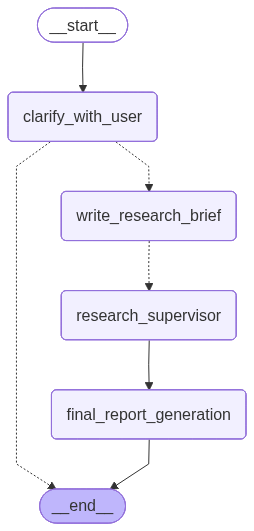

Graph visualization displayed above


In [19]:
from IPython.display import Image, display

# Method 1: Display as PNG image (recommended for notebooks)
try:
    # Generate the graph visualization as PNG
    png_data = graph.get_graph().draw_mermaid_png()
    display(Image(png_data))
    print("Graph visualization displayed above")
except Exception as e:
    print(f"PNG visualization not available: {e}")
    print("\nFalling back to ASCII representation:\n")
    
    # Method 2: ASCII art (fallback if PNG doesn't work)
    try:
        ascii_graph = graph.get_graph().draw_ascii()
        print(ascii_graph)
    except Exception as e2:
        print(f"ASCII visualization failed: {e2}")
        
        # Method 3: Print Mermaid syntax (can paste into mermaid.live)
        print("\nMermaid diagram syntax (paste into https://mermaid.live):\n")
        mermaid_syntax = graph.get_graph().draw_mermaid()
        print(mermaid_syntax)


### Understanding the Flow Diagram

The diagram above shows the complete execution flow of the Deep Research system:

**Main Graph Nodes (Top Level):**
- **START** → Entry point for user queries
- **clarify_with_user** → Asks clarifying questions if needed
- **write_research_brief** → Transforms user input into structured brief
- **research_supervisor** → Subgraph that manages research delegation
- **final_report_generation** → Synthesizes all findings into final report
- **END** → Exit point with final results

**Inside the research_supervisor Subgraph:**
- **supervisor** → Plans research strategy and delegates tasks
- **supervisor_tools** → Executes delegations and spawns parallel researchers
- Each researcher runs in its own subgraph with search tools

**Key Flow Patterns:**
1. Linear progression: START → clarify → brief → supervisor → report → END
2. Potential loop: Supervisor can iterate multiple times for thorough research
3. Parallel execution: Multiple researchers work simultaneously (not visible in this diagram)
4. Conditional branching: Clarification may skip directly to brief if not needed


In [20]:
# Alternative: Inspect the graph structure programmatically
print("Graph Structure Information:\n")
print("="*60)

# Get the compiled graph
graph_structure = graph.get_graph()

# Display node information
print(f"Total Nodes: {len(graph_structure.nodes)}")
print(f"\nNode Names:")
for node_id, node_data in graph_structure.nodes.items():
    print(f"  - {node_id}")

# Display edge information
print(f"\nTotal Edges: {len(graph_structure.edges)}")
print(f"\nEdge Connections:")
for edge in graph_structure.edges:
    print(f"  {edge.source} → {edge.target}")

print("\n" + "="*60)

# Export Mermaid syntax for external visualization
print("\nTo visualize this graph externally:")
print("1. Copy the Mermaid syntax below")
print("2. Paste it into https://mermaid.live")
print("3. Customize colors, styles, and layout\n")

print("Mermaid Syntax:")
print("-"*60)
mermaid_code = graph.get_graph().draw_mermaid()
print(mermaid_code)


Graph Structure Information:

Total Nodes: 6

Node Names:
  - __start__
  - clarify_with_user
  - write_research_brief
  - research_supervisor
  - final_report_generation
  - __end__

Total Edges: 6

Edge Connections:
  __start__ → clarify_with_user
  clarify_with_user → __end__
  clarify_with_user → write_research_brief
  research_supervisor → final_report_generation
  write_research_brief → research_supervisor
  final_report_generation → __end__


To visualize this graph externally:
1. Copy the Mermaid syntax below
2. Paste it into https://mermaid.live
3. Customize colors, styles, and layout

Mermaid Syntax:
------------------------------------------------------------
---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	clarify_with_user(clarify_with_user)
	write_research_brief(write_research_brief)
	research_supervisor(research_supervisor)
	final_report_generation(final_report_generation)
	__end__([<p>__end__</p>]):::last
	__start__ --> cl

### Visualizing Individual Subgraphs

You can also visualize the individual subgraphs (supervisor and researcher) to see their internal structure:


SUPERVISOR SUBGRAPH

This subgraph manages research delegation and coordination.



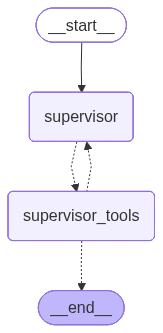


RESEARCHER SUBGRAPH

This subgraph represents a single researcher conducting focused research.



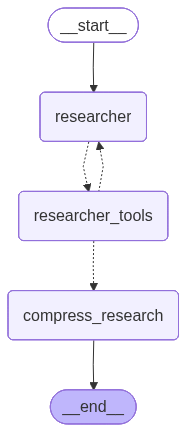



Note: During execution, the supervisor spawns multiple instances
of the researcher subgraph in parallel (up to max_concurrent_research_units).


In [21]:
from open_deep_library.deep_researcher import supervisor_subgraph, researcher_subgraph

print("="*60)
print("SUPERVISOR SUBGRAPH")
print("="*60)
print("\nThis subgraph manages research delegation and coordination.\n")

try:
    # Visualize supervisor subgraph
    supervisor_png = supervisor_subgraph.get_graph().draw_mermaid_png()
    display(Image(supervisor_png))
except Exception as e:
    print(f"PNG not available, showing ASCII:\n")
    print(supervisor_subgraph.get_graph().draw_ascii())

print("\n" + "="*60)
print("RESEARCHER SUBGRAPH")
print("="*60)
print("\nThis subgraph represents a single researcher conducting focused research.\n")

try:
    # Visualize researcher subgraph
    researcher_png = researcher_subgraph.get_graph().draw_mermaid_png()
    display(Image(researcher_png))
except Exception as e:
    print(f"PNG not available, showing ASCII:\n")
    print(researcher_subgraph.get_graph().draw_ascii())

print("\n" + "="*60)
print("\nNote: During execution, the supervisor spawns multiple instances")
print("of the researcher subgraph in parallel (up to max_concurrent_research_units).")
print("="*60)


### Configuration for Anthropic

We'll configure the system to use:
- **Claude Sonnet 4** for all research, supervision, and report generation
- **Tavily** for web search (you can also use Anthropic's native search)
- **Moderate parallelism** (3 concurrent researchers)
- **Clarification enabled** (will ask if research scope is unclear)

In [17]:
# Configure for Anthropic with moderate settings
config = {
    "configurable": {
        # Model configuration - using Claude Sonnet 4 for everything
        "research_model": "anthropic:claude-sonnet-4-20250514",
        "research_model_max_tokens": 10000,
        
        "compression_model": "anthropic:claude-sonnet-4-20250514",
        "compression_model_max_tokens": 8192,
        
        "final_report_model": "anthropic:claude-sonnet-4-20250514",
        "final_report_model_max_tokens": 10000,
        
        "summarization_model": "anthropic:claude-sonnet-4-20250514",
        "summarization_model_max_tokens": 8192,
        
        # Research behavior
        "allow_clarification": True,
        "max_concurrent_research_units": 1,  # 1 parallel researchers
        "max_researcher_iterations": 2,      # Supervisor can delegate up to 2 times
        "max_react_tool_calls": 3,           # Each researcher can make up to 3 tool calls
        
        # Search configuration
        "search_api": "tavily",  # Using Tavily for web search
        "max_content_length": 50000,
        
        # Thread ID for this conversation
        "thread_id": str(uuid.uuid4())
    }
}

print("✓ Configuration ready")
print(f"  - Research Model: Claude Sonnet 4")
print(f"  - Max Concurrent Researchers: 3")
print(f"  - Max Iterations: 4")
print(f"  - Search API: Tavily")

✓ Configuration ready
  - Research Model: Claude Sonnet 4
  - Max Concurrent Researchers: 3
  - Max Iterations: 4
  - Search API: Tavily


### Execute the Research

Now let's run the research! We'll ask the system to analyze the PDF and provide insights about how people use AI.

The workflow will:
1. **Clarify** - Check if the request is clear (may skip if obvious)
2. **Research Brief** - Transform our request into a structured brief
3. **Supervisor** - Plan research strategy and delegate to researchers
4. **Parallel Research** - Multiple researchers gather information simultaneously
5. **Compression** - Each researcher synthesizes their findings
6. **Final Report** - All findings combined into comprehensive report

In [18]:
# Create our research request with PDF context
research_request = f"""
I have a PDF document about how people use AI. Please analyze this document and provide insights about:

1. What are the main findings about how people are using AI?
2. What are the most common use cases?
3. What trends or patterns emerge from the data?

Here's the PDF content:

{pdf_content[:10000]}  # First 10k chars to stay within limits

...[content truncated for context window]
"""

# Execute the graph
async def run_research():
    """Run the research workflow and display results."""
    print("Starting research workflow...\n")
    
    async for event in graph.astream(
        {"messages": [{"role": "user", "content": research_request}]},
        config,
        stream_mode="updates"
    ):
        # Display each step
        for node_name, node_output in event.items():
            print(f"\n{'='*60}")
            print(f"Node: {node_name}")
            print(f"{'='*60}")
            
            if node_name == "clarify_with_user":
                if "messages" in node_output:
                    last_msg = node_output["messages"][-1]
                    print(f"\n{last_msg.content}")
            
            elif node_name == "write_research_brief":
                if "research_brief" in node_output:
                    print(f"\nResearch Brief Generated:")
                    print(f"{node_output['research_brief'][:500]}...")
            
            elif node_name == "supervisor":
                print(f"\nSupervisor planning research strategy...")
                if "supervisor_messages" in node_output:
                    last_msg = node_output["supervisor_messages"][-1]
                    if hasattr(last_msg, 'tool_calls') and last_msg.tool_calls:
                        print(f"Tool calls: {len(last_msg.tool_calls)}")
                        for tc in last_msg.tool_calls:
                            print(f"  - {tc['name']}")
            
            elif node_name == "supervisor_tools":
                print(f"\nExecuting supervisor's tool calls...")
                if "notes" in node_output:
                    print(f"Research notes collected: {len(node_output['notes'])}")
            
            elif node_name == "final_report_generation":
                if "final_report" in node_output:
                    print(f"\n" + "="*60)
                    print("FINAL REPORT GENERATED")
                    print("="*60 + "\n")
                    display(Markdown(node_output["final_report"]))
    
    print("\n" + "="*60)
    print("Research workflow completed!")
    print("="*60)

# Run the research
await run_research()

Starting research workflow...


Node: clarify_with_user

I have sufficient information to proceed with your analysis request. You've provided a comprehensive NBER working paper titled "How People Use ChatGPT" with detailed research data, and you've clearly outlined three specific areas for analysis:

1. Main findings about how people are using AI
2. Most common use cases  
3. Trends and patterns from the data

The document contains rich quantitative data about ChatGPT usage patterns, user demographics, growth metrics, and detailed classifications of message types. I will now analyze this research paper and provide insights covering all three areas you've requested, drawing from the study's findings about user behavior, adoption patterns, and usage evolution over time.

Node: write_research_brief

Research Brief Generated:
I need a comprehensive analysis of the NBER working paper "How People Use ChatGPT" by Chatterji et al. (2025) to extract insights about AI usage patterns. Specificall

# Comprehensive Analysis of "How People Use ChatGPT" - NBER Working Paper by Chatterji et al. (2025)

## Main Findings About AI Usage Patterns

The NBER working paper "How People Use ChatGPT" by Chatterji et al. (2025) presents unprecedented insights into the adoption and usage patterns of ChatGPT, representing the largest study to date of consumer AI usage based on internal message data from 1.5 million conversations [1][2][3].

### Unprecedented Growth and Adoption Scale

ChatGPT achieved remarkable adoption metrics that surpass any previous technology diffusion. By July 2025, the platform reached over 700 million weekly active users, representing approximately 10% of the world's adult population [1][2][4]. This growth trajectory is historically unprecedented - ChatGPT gained 1 million users within 5 days of its November 2022 launch and reached 100 million weekly active users in under a year [2]. The platform has been doubling its user base every 7-8 months since launch [2].

The scale of engagement is equally impressive. As of June 2025, users were sending more than 2.6 billion messages per day, equivalent to over 30,000 messages per second [2]. Message volume grew 5.8x in the past year while user volume grew 3.2x, indicating that existing users are becoming significantly more engaged over time rather than growth being driven purely by new user acquisition [2].

### Demographic Evolution and Patterns

The study reveals dramatic shifts in user demographics over time. Initially, over 80% of users had typically male names, but by July 2025, this completely reversed with 52% having typically female names [2][5]. This gender gap closure represents one of the most significant demographic transitions documented in technology adoption.

Age demographics show concentrated usage among younger populations, with users aged 18-25 sending 46% of all messages, though older groups are gaining share over time [4]. Nearly half of all messages come from users under 26, highlighting ChatGPT's particular appeal to digital natives [1].

### Geographic and Socioeconomic Adoption Patterns

The research documents fascinating global adoption patterns that defy traditional technology diffusion models. Higher growth rates were consistently found in lower-income countries compared to higher-income ones [6][7]. Middle-income countries showed 5-6x growth compared to 3x growth in the richest countries, with countries like Brazil, South Korea, and the US now showing similar usage rates despite vastly different GDP levels [2]. Low-income countries have seen 4x growth in adoption compared to high-income countries [4].

This pattern suggests ChatGPT may be democratizing access to advanced AI capabilities across economic boundaries in ways previous technologies have not achieved.

### Behavioral Changes and Usage Evolution

The study reveals significant behavioral changes within user cohorts over time. All signup cohorts showed relatively flat usage through most of 2024, then experienced substantial increases beginning in early 2025, suggesting ChatGPT became significantly better or more user-friendly [2]. Early adopters from Q1 2023 were sending 40% more messages by July 2025 than two years earlier, while users who signed up in late 2024 nearly doubled their usage within less than a year [2].

## Most Common Use Cases and Classification Systems

### Primary Use Case Categories

The researchers developed sophisticated classification taxonomies using privacy-preserving automated pipelines to categorize ChatGPT usage. The three most common conversation topics - "Practical Guidance," "Seeking Information," and "Writing" - collectively account for nearly 80% of all conversations [1][6][7].

**Practical Guidance** emerges as the most common use case, encompassing activities like tutoring and teaching, how-to advice across various topics, and creative ideation. Over 10% of all messages specifically involve tutoring/teaching functions [4]. This category highlights ChatGPT's role as an advisory tool rather than purely an automation platform.

**Seeking Information** functions as a close substitute for traditional web search, including searches for information about people, current events, products, and recipes. This category demonstrates ChatGPT's competition with traditional search engines in information retrieval tasks.

**Writing** includes automated production of emails, documents, and communications, but extends significantly to editing, critiquing, summarizing, and translating text provided by users. This category showcases ChatGPT's unique ability to generate and manipulate digital outputs compared to traditional search engines.

### User Intent Classification Framework

The study introduces an innovative "Asking/Doing/Expressing" taxonomy to categorize user interactions [7]. The distribution shows that nearly half of all prompts (49%) are 'Asking' - seeking advice, clarity, or decision support, making ChatGPT function more as a thinking partner than a task automation tool [5]. 'Doing' activities account for approximately 40% of interactions, while 'Expressing' represents about 11% [1].

### Work vs. Non-Work Usage Dynamics

One of the study's most significant findings concerns the dramatic shift in work versus personal usage patterns. Non-work messages grew from 53% in mid-2024 to over 70% in mid-2025 [1][6][7]. This trend represents a fundamental evolution in how consumers integrate AI into their daily lives, with personal applications growing faster than professional ones.

### Professional Usage Patterns

Among work-related messages, writing dominates professional tasks, accounting for 40-42% of such messages in June 2025 [1][4]. The composition of work-related usage breaks down as follows: 42% involves writing (mostly editing rather than creating from scratch), 24% seeks practical guidance, and 10% requests technical help [4]. Work usage correlates strongly with higher education levels and employment in highly-paid professional occupations [6][7].

Contrary to popular assumptions about AI and programming, computer coding represents only about 4.2-4.3% of total messages [1][4]. This finding challenges narratives that position AI primarily as a coding assistant and reveals much broader applications across knowledge work.

The study identified 2,087 different individual work tasks being performed through ChatGPT, demonstrating the platform's versatility across professional contexts [4].

## Trends and Patterns in AI Usage Evolution

### The Shift from Professional to Personal Applications

The most striking trend documented in the research is the sustained shift from work-related to personal applications. The movement from 53% personal usage in mid-2024 to 73% personal usage by mid-2025 represents a fundamental change in how consumers perceive and utilize AI tools [5][6]. This shift occurs primarily due to changing usage patterns within existing user cohorts rather than changes in the composition of new users joining the platform.

This trend suggests that while initial AI adoption may be driven by professional curiosity and workplace applications, sustained engagement increasingly centers on personal utility and integration into daily life activities outside of work.

### Evolving User Engagement Patterns

The study reveals that ChatGPT is becoming increasingly integrated into users' weekly and daily routines [2]. Message volume growth significantly outpacing user growth (5.8x vs 3.2x) indicates that existing users are finding more applications and becoming more dependent on the platform over time [2].

All user cohorts, regardless of when they joined, showed substantial usage increases beginning in early 2025, suggesting significant improvements in the platform's capabilities or user experience that drove broader adoption within existing user bases [2].

### Comparison with Traditional Information Platforms

The research provides crucial context by comparing ChatGPT's growth trajectory with established platforms. Currently, there are an estimated 14 billion Google web searches each day. If ChatGPT message volume continues on its current growth path, it would equal the number of current Google searches in just over a year [2]. 

This comparison is particularly striking when considering adoption timelines. While Google took eight years to reach 1 billion daily searches after its 1999 launch, ChatGPT achieved 1 billion daily messages in less than two years [2]. This acceleration suggests fundamental differences in how users integrate conversational AI compared to traditional search interfaces.

### User Satisfaction and Retention Patterns

The study documents high user satisfaction levels, with positive interactions outnumbering negative ones by approximately 4:1 [1]. This satisfaction translates into sustained engagement, with users across all cohorts increasing their usage over time rather than experiencing typical technology adoption decline patterns.

## Economic Implications and Value Creation

### Consumer Surplus and Economic Value

The research provides groundbreaking insights into the economic value generated by AI chatbots. The study suggests AI's unmeasured consumer surplus reaches approximately $100 billion annually, demonstrating significant economic impact that extends beyond traditional productivity indicators [4]. This aligns with findings from Collis and Brynjolfsson (2025), who estimated consumer surplus of at least $97 billion in 2024 alone in the US through choice experiments measuring willingness-to-pay for generative AI [1].

Consumer surplus helps explain how ChatGPT can generate substantial economic impact even when most users pay nothing for access. The usefulness may far exceed the price, generating significant surplus value that traditional economic measurements fail to capture [4]. This represents a new form of economic benefit that doesn't immediately appear in GDP statistics but creates real value for consumers [8].

### Decision Support as Primary Value Driver

The researchers conclude that ChatGPT provides economic value primarily through decision support, which proves particularly important in knowledge-intensive jobs [6][7]. Rather than functioning primarily as an automation tool, ChatGPT's strongest economic value emerges as a decision-support system [1]. The prevalence of 'Asking' interactions (49% of all prompts) seeking advice, clarity, or decision support reinforces this finding [5].

This decision-support function represents a fundamental shift in how AI creates economic value - not by replacing human judgment but by augmenting human decision-making processes with enhanced information processing and analysis capabilities.

### Unique Value Proposition vs Traditional Tools

The dominance of writing tasks in work-related usage highlights chatbots' unique ability to generate and manipulate digital outputs compared to traditional search engines [6][7]. While search engines excel at information retrieval, ChatGPT's capacity to create, edit, summarize, and transform content represents a distinctly different value proposition.

The study documents a shift toward "advisory" interactions rather than pure "automation" functions, suggesting users leverage ChatGPT more for guidance and support rather than complete task automation [7]. This positions AI chatbots as cognitive enhancement tools rather than job replacement technologies.

### Broader Economic and Social Implications

The research suggests this may be the first powerful technology in history that consumers can access as quickly as the world's leading companies [4]. This democratization of advanced AI capabilities has profound implications for global economic development, particularly given the higher adoption rates in lower-income countries.

The findings have significant implications for productivity measurement, product design, and policy development as AI tools become more integrated into daily workflows and personal tasks [7]. Traditional economic indicators may substantially undervalue the economic impact of AI technologies that generate high consumer surplus while requiring minimal direct payment.

## Methodology and Research Innovation

### Privacy-Preserving Research Protocols

The study establishes new standards for privacy-preserving AI research through sophisticated methodological innovations. Researchers never accessed raw user data, personal information, or message content [2]. All analyses were conducted on messages automatically stripped of names, dates of birth, addresses, and any other personally identifiable information [2].

The research employed automated classifiers and a secure Data Clean Room system that provided only aggregate outputs [2]. All data processing involved multiple approval cycles with public logging to ensure transparency while maintaining privacy [2]. This methodology enables large-scale behavioral research while protecting individual user privacy.

### Classification System Innovation

The study introduces several novel classification taxonomies applied through automated LLM-based classifiers. These include work/non-work categorization, conversation topic classification, user intent analysis (Asking/Doing/Expressing), and O*NET task mapping. Each taxonomy was defined through carefully crafted prompts passed to LLMs, allowing message classification without human researchers viewing content.

The classification pipeline was validated through multiple methodologies detailed in the study's appendices, ensuring accuracy while maintaining privacy protections. This approach represents a significant methodological advancement for studying user behavior at scale.

### Study Scope and Collaboration

The research analyzed over 1.5 million de-identified ChatGPT conversations from May 2024 through June 2025, representing the largest sample of actual AI usage studied to date [4][7]. The study was conducted collaboratively by researchers from Duke University, Harvard University, and OpenAI, with Harvard IRB approval [6].

This collaboration between academic institutions and the platform provider enabled unprecedented access to usage data while maintaining rigorous academic research standards and privacy protections.

## Conclusion

The NBER working paper "How People Use ChatGPT" provides the first comprehensive, empirically-grounded analysis of how consumers actually use large language model chatbots at scale. The findings reveal AI adoption patterns that defy conventional technology diffusion models, with particularly rapid growth in lower-income countries and a dramatic shift from male-dominated to gender-balanced usage.

The research demonstrates that AI chatbots create economic value primarily through decision support rather than task automation, generating substantial consumer surplus that traditional economic measurements fail to capture. The dominance of personal over professional applications, growing from 53% to over 70% of usage, suggests AI's impact on home production and daily life activities may equal or exceed its workplace productivity effects.

Most significantly, the study reveals ChatGPT functions more as a thinking partner than a task automation tool, with nearly half of all interactions involving users seeking advice and guidance. This positions conversational AI as a cognitive enhancement technology that augments human decision-making rather than simply replacing human tasks.

These findings have profound implications for understanding AI's economic impact, measuring productivity in the digital economy, and designing policies for AI integration in society. As ChatGPT approaches the scale of Google Search in daily interactions, its role as a decision-support platform represents a fundamental shift in how humans access and utilize information for both work and personal applications.

### Sources

[1] How People Really Use ChatGPT: Findings from NBER Research: https://techmaniacs.com/2025/09/15/how-people-really-use-chatgpt-findings-from-nber-research/

[2] How People Use ChatGPT - by David Deming - Forked Lightning: https://forklightning.substack.com/p/how-people-use-chatgpt

[3] How People Use ChatGPT | NBER: https://www.nber.org/papers/w34255

[4] How the World is Using ChatGPT: https://openaiglobalaffairs.substack.com/p/how-the-world-is-using-chatgpt

[5] how people use chatgpt - Medium: https://medium.com/@danny_54172/how-people-use-chatgpt-842c0427182a

[6] How People Actually Use ChatGPT — What 1.5M Conversations Tell Us: https://medium.com/@adnanmasood/how-people-actually-use-chatgpt-what-1-5m-conversations-tell-us-about-the-next-decade-of-software-ea603212b458

[7] How People Use ChatGPT - SSRN: https://papers.ssrn.com/sol3/papers.cfm?abstract_id=5487080

[8] Event Replay: How People Really Use ChatGPT - OpenAI Forum: https://forum.openai.com/public/videos/event-replay-how-people-really-use-chatgpt-the-who-the-what-and-the-how-of-chatgpt-2025-08-27


Research workflow completed!


## Understanding the Output

Let's break down what happened:

### Phase 1: Clarification
The system checked if your request was clear. Since you provided a PDF and specific questions, it likely proceeded without clarification.

### Phase 2: Research Brief
Your request was transformed into a detailed research brief that guides the supervisor's delegation strategy.

### Phase 3: Supervisor Delegation
The supervisor analyzed the brief and decided how to break down the research:
- Used `think_tool` to plan strategy
- Called `ConductResearch` multiple times to delegate to parallel researchers
- Each delegation specified a focused research topic

### Phase 4: Parallel Research
Multiple researchers worked simultaneously:
- Each researcher used web search tools to gather information
- Used `think_tool` to reflect after each search
- Decided when they had enough information
- Compressed their findings into clean summaries

### Phase 5: Final Report
All research findings were synthesized into a comprehensive report with:
- Well-structured sections
- Inline citations
- Sources listed at the end
- Balanced coverage of all findings

#### 🏗️ Activity #1: Try Different Configurations

You can experiment with different settings to see how they affect the research.  You may select three or more of the following settings (or invent your own experiments) and describe the results.

### Increase Parallelism
```python
"max_concurrent_research_units": 10  # More researchers working simultaneously
```

### Deeper Research
```python
"max_researcher_iterations": 8   # Supervisor can delegate more times
"max_react_tool_calls": 15      # Each researcher can search more
```

### Use Anthropic Native Search
```python
"search_api": "anthropic"  # Use Claude's built-in web search
```

### Disable Clarification
```python
"allow_clarification": False  # Skip clarification phase
```

### ✅ ANSWER:
This was done in a separate notebook here: [Configuration Experiments](configuration_experiments.ipynb) 

## Key Takeaways

### Architecture Benefits
1. **Dynamic Decomposition** - Research structure emerges from the question, not predefined
2. **Parallel Efficiency** - Multiple researchers work simultaneously
3. **ReAct Quality** - Strategic reflection improves search decisions
4. **Scalability** - Handles token limits gracefully through compression
5. **Flexibility** - Easy to add new tools and capabilities

### When to Use This Pattern
- **Complex research questions** that need multi-angle investigation
- **Comparison tasks** where parallel research on different topics is beneficial
- **Open-ended exploration** where structure should emerge dynamically
- **Time-sensitive research** where parallel execution speeds up results

### When to Use Section-Based Instead
- **Highly structured reports** with predefined format requirements
- **Template-based content** where sections are always the same
- **Sequential dependencies** where later sections depend on earlier ones
- **Budget constraints** where token efficiency is critical

## Next Steps

### Extend the System
1. **Add MCP Tools** - Integrate specialized tools for your domain
2. **Custom Prompts** - Modify prompts for specific research types
3. **Different Models** - Try different Claude versions or mix models
4. **Persistence** - Use a real database for checkpointing instead of memory

### Learn More
- [LangGraph Documentation](https://langchain-ai.github.io/langgraph/)
- [Open Deep Research Repo](https://github.com/langchain-ai/open_deep_research)
- [Anthropic Claude Documentation](https://docs.anthropic.com/)
- [Tavily Search API](https://tavily.com/)

### Deploy
- Use LangGraph Cloud for production deployment
- Add proper error handling and logging
- Implement rate limiting and cost controls
- Monitor research quality and costs